<a href="https://colab.research.google.com/github/MarianaCelisBougard/Taller_NNA_Grupo4/blob/main/Data_Preparation/Data_Preparation_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# -*- coding: utf-8 -*-
"""
==============================================================================
CRISP-DM FASE 3: DATA PREPARATION PARA ANÁLISIS DE CORRESPONDENCIAS (MCA)
Proyecto: Caracterización de NNA en Programas de Intervención
Notebook 2 de 4 - Preparación Simplificada de Datos
==============================================================================
"""

# ==============================================================================
# 1. CONFIGURACIÓN INICIAL
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 80)
print("CRISP-DM FASE 3: DATA PREPARATION PARA MCA")
print("Proyecto: Caracterización de NNA en Trabajo Infantil")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRISP-DM FASE 3: DATA PREPARATION PARA MCA
Proyecto: Caracterización de NNA en Trabajo Infantil
Fecha de ejecución: 2025-10-16 17:21:18


In [24]:
# ==============================================================================
# 2. CARGA DE DATOS FILTRADOS (DESDE NOTEBOOK 1- DATA-UNDERSTANDING)
# ==============================================================================

ruta = '/content/drive/MyDrive/Python/Proyecto NNA/datos_filtrados.xlsx'

print("\n Cargando datos desde DATA-UNDERSTANDING...")
datos_filtrados = pd.read_excel(ruta, sheet_name='Datos_filtrados')

print(f"✅ Datos cargados exitosamente")
print(f"   - Dataset: {datos_filtrados.shape[0]:,} registros × {datos_filtrados.shape[1]} columnas")

# Backup
datos_originales = datos_filtrados.copy()


 Cargando datos desde DATA-UNDERSTANDING...
✅ Datos cargados exitosamente
   - Dataset: 56,473 registros × 28 columnas


In [25]:
# ==============================================================================
# 3. SELECCIÓN DE VARIABLES CATEGÓRICAS RELEVANTES
# ==============================================================================

print("\n" + "=" * 80)
print(" ---SELECCIÓN DE VARIABLES PARA MCA --- ")
print("=" * 80)

# Variables categóricas principales
variables_categoricas = [
    'SEXO',
    'ESTRATO',
    'Localidad_fic',  # Usar la de mejor completitud
    'TIPO INTERVENCIÓN',
    'NACIONALIDAD',
    'ESTADO CIVIL',
    'ETNIA',
    'POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN',
    'OCUPACIÓN',
    'CATEGORÍAS DE LA DISCAPACIDAD',
    'VÍNCULO CON EL JEFE DE HOGAR',
    'ZONA',
    'BARRIO PRIORIZADO',
    'MANZANA DEL CUIDADO',
    'AFILIACIÓN AL SGSSS.1',
    '¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?',
    'INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO',
    'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL'
]

# Verificar cuáles existen en el dataset
variables_disponibles = [v for v in variables_categoricas if v in datos_filtrados.columns]
variables_faltantes = [v for v in variables_categoricas if v not in datos_filtrados.columns]

print(f"\n✅ Variables categóricas disponibles: {len(variables_disponibles)}")
for var in variables_disponibles:
    print(f"   • {var}")

if variables_faltantes:
    print(f"\n Variables no encontradas: {len(variables_faltantes)}")
    for var in variables_faltantes:
        print(f"   - {var}")


 ---SELECCIÓN DE VARIABLES PARA MCA --- 

✅ Variables categóricas disponibles: 18
   • SEXO
   • ESTRATO
   • Localidad_fic
   • TIPO INTERVENCIÓN
   • NACIONALIDAD
   • ESTADO CIVIL
   • ETNIA
   • POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN
   • OCUPACIÓN
   • CATEGORÍAS DE LA DISCAPACIDAD
   • VÍNCULO CON EL JEFE DE HOGAR
   • ZONA
   • BARRIO PRIORIZADO
   • MANZANA DEL CUIDADO
   • AFILIACIÓN AL SGSSS.1
   • ¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?
   • INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO
   • NNA DESVINCULADO DE LA ACTIVIDAD LABORAL


In [26]:
# ==============================================================================
# 4. DISCRETIZACIÓN DE VARIABLES NUMÉRICAS CLAVE
# ==============================================================================

print("\n" + "=" * 80)
print("---DISCRETIZACIÓN DE VARIABLES NUMÉRICAS---")
print("=" * 80)

nuevas_categoricas = []

# 4.1 EDAD → EDAD_GRUPO
if 'EDAD' in datos_filtrados.columns:
    print(f"\n  Discretizando EDAD → EDAD_GRUPO")

    datos_filtrados['EDAD_GRUPO'] = pd.cut(
        datos_filtrados['EDAD'],
        bins=[0, 5, 10, 14, 18, 100],
        labels=['0-5_Primera_Infancia', '6-10_Infancia', '11-14_Preadolescencia', '15-18_Adolescencia', '18+_Joven'],
        include_lowest=True
    )

    # Convertir a string
    datos_filtrados['EDAD_GRUPO'] = datos_filtrados['EDAD_GRUPO'].astype(str)

    nuevas_categoricas.append('EDAD_GRUPO')
    print(f"   ✅ EDAD_GRUPO creada")
    print(f"   Distribución:")
    print(datos_filtrados['EDAD_GRUPO'].value_counts().sort_index())

# 4.2 UPZ/UPR → UPZ_DENSIDAD (opcional, si tiene sentido territorial)
if 'UPZ/UPR' in datos_filtrados.columns:
    print(f"\n Discretizando UPZ/UPR → UPZ_DENSIDAD")

    # Agrupar por cuartiles
    try:
        datos_filtrados['UPZ_DENSIDAD'] = pd.qcut(
            datos_filtrados['UPZ/UPR'],
            q=4,
            labels=['UPZ_Baja_Densidad', 'UPZ_Media_Baja', 'UPZ_Media_Alta', 'UPZ_Alta_Densidad'],
            duplicates='drop'
        ).astype(str)

        nuevas_categoricas.append('UPZ_DENSIDAD')
        print(f"   ✅ UPZ_DENSIDAD creada")
        print(f"   Distribución:")
        print(datos_filtrados['UPZ_DENSIDAD'].value_counts())
    except Exception as e:
        print(f"   No se pudo crear UPZ_DENSIDAD: {e}")

# 4.3 ANTIGÜEDAD → FASE_PROGRAMA
if 'Fecha_intervencion' in datos_filtrados.columns:
    print(f"\n Calculando FASE_PROGRAMA desde Fecha_intervencion")

    try:
        # Convertir a datetime
        datos_filtrados['Fecha_intervencion'] = pd.to_datetime(
            datos_filtrados['Fecha_intervencion'],
            errors='coerce'
        )

        # Calcular antigüedad
        fecha_ref = pd.Timestamp.now()
        antiguedad_dias = (fecha_ref - datos_filtrados['Fecha_intervencion']).dt.days

        # Validar rango (solo 2015-hoy)
        antiguedad_dias = antiguedad_dias.clip(lower=0, upper=3650)  # Max 10 años

        # Discretizar
        datos_filtrados['FASE_PROGRAMA'] = pd.cut(
            antiguedad_dias,
            bins=[0, 180, 720, 3650],
            labels=['Fase_Reciente_0-6m', 'Fase_Seguimiento_6m-2a', 'Fase_Prolongada_mas2a'],
            include_lowest=True
        ).astype(str)

        nuevas_categoricas.append('FASE_PROGRAMA')
        print(f"   ✅ FASE_PROGRAMA creada")
        print(f"   Distribución:")
        print(datos_filtrados['FASE_PROGRAMA'].value_counts())
    except Exception as e:
        print(f"  No se pudo crear FASE_PROGRAMA: {e}")

print(f"\n📊 Total de variables categóricas nuevas: {len(nuevas_categoricas)}")


---DISCRETIZACIÓN DE VARIABLES NUMÉRICAS---

  Discretizando EDAD → EDAD_GRUPO
   ✅ EDAD_GRUPO creada
   Distribución:
EDAD_GRUPO
0-5_Primera_Infancia      8407
11-14_Preadolescencia     8147
15-18_Adolescencia        4445
6-10_Infancia            10746
nan                      24728
Name: count, dtype: int64

 Discretizando UPZ/UPR → UPZ_DENSIDAD
   ✅ UPZ_DENSIDAD creada
   Distribución:
UPZ_DENSIDAD
UPZ_Media_Alta       12449
UPZ_Baja_Densidad    11790
UPZ_Media_Baja       11772
UPZ_Alta_Densidad    10810
nan                   9652
Name: count, dtype: int64

 Calculando FASE_PROGRAMA desde Fecha_intervencion
   ✅ FASE_PROGRAMA creada
   Distribución:
FASE_PROGRAMA
Fase_Prolongada_mas2a     38062
Fase_Seguimiento_6m-2a    18411
Name: count, dtype: int64

📊 Total de variables categóricas nuevas: 3


In [27]:
# ==============================================================================
# 5. CONSTRUCCIÓN DEL DATASET PARA MCA
# ==============================================================================

print("\n" + "=" * 80)
print("---CONSTRUCCIÓN DEL DATASET PARA MCA---")
print("=" * 80)

# Lista completa de variables para MCA
variables_mca = variables_disponibles + nuevas_categoricas

print(f"\n Variables seleccionadas para MCA: {len(variables_mca)}")

# Crear dataset
datos_mca = datos_filtrados[variables_mca].copy()

print(f"\n✅ Dataset MCA creado:")
print(f"   - Dimensiones: {datos_mca.shape[0]:,} × {datos_mca.shape[1]}")




---CONSTRUCCIÓN DEL DATASET PARA MCA---

 Variables seleccionadas para MCA: 21

✅ Dataset MCA creado:
   - Dimensiones: 56,473 × 21


In [28]:
# ==============================================================================
# 6. LIMPIEZA Y ESTANDARIZACIÓN DE CATEGORÍAS
# ==============================================================================

print("\n" + "=" * 80)
print(" LIMPIEZA DE CATEGORÍAS")
print("=" * 80)

# 6.1 Convertir todo a string
print(f"\n Convirtiendo todas las variables a tipo string...")
datos_mca = datos_mca.astype(str)
print(f"   ✅ Conversión completada")

# 6.2 Imputar valores faltantes
print(f"\n Imputando valores faltantes...")
faltantes_antes = datos_mca.isna().sum().sum()
faltantes_antes += (datos_mca == 'nan').sum().sum()  # Contar 'nan' como string

# Reemplazar 'nan', 'None', NaN por 'No_reporta'
datos_mca = datos_mca.replace(['nan', 'None', 'NaN', 'NA'], 'No_reporta')
datos_mca = datos_mca.fillna('No_reporta')

faltantes_despues = (datos_mca == 'No_reporta').sum().sum()
print(f"   ✅ Valores 'No_reporta' imputados: {faltantes_despues:,}")

# 6.3 Limpiar espacios y estandarizar
print(f"\n Estandarizando formato de categorías...")
for col in datos_mca.columns:
    # Quitar espacios extra
    datos_mca[col] = datos_mca[col].str.strip()
    # Reemplazar múltiples espacios por uno
    datos_mca[col] = datos_mca[col].str.replace(r'\s+', ' ', regex=True)

print(f"   ✅ Formato estandarizado")

# 6.4 Análisis de cardinalidad
print(f"\n Análisis de cardinalidad por variable:")
print(f"\n{'Variable':<50} {'Categorías':<10} {'Más frecuente':<20} {'%':<8}")
print("-" * 90)

for col in datos_mca.columns:
    n_categorias = datos_mca[col].nunique()
    valor_mas_frecuente = datos_mca[col].value_counts().index[0]
    freq_max = datos_mca[col].value_counts().iloc[0]
    pct_max = (freq_max / len(datos_mca)) * 100

    # Truncar nombre si es muy largo
    col_display = col[:47] + "..." if len(col) > 50 else col
    valor_display = valor_mas_frecuente[:17] + "..." if len(valor_mas_frecuente) > 20 else valor_mas_frecuente

    print(f"{col_display:<50} {n_categorias:<10} {valor_display:<20} {pct_max:>6.1f}%")

# 6.5 Detectar variables con muy alta cardinalidad (problemáticas para MCA)
print(f"\n Detección de variables problemáticas:")
variables_alta_cardinalidad = []

for col in datos_mca.columns:
    n_categorias = datos_mca[col].nunique()
    pct_categorias = (n_categorias / len(datos_mca)) * 100

    # Si >50 categorías o >10% de registros únicos
    if n_categorias > 50 or pct_categorias > 10:
        variables_alta_cardinalidad.append((col, n_categorias, pct_categorias))

if variables_alta_cardinalidad:
    print(f"\n    Variables con alta cardinalidad detectadas:")
    for var, n_cat, pct in variables_alta_cardinalidad:
        print(f"      - {var}: {n_cat} categorías ({pct:.1f}%)")

    print(f"\n   Recomendación: Considerar agrupar categorías poco frecuentes")
    print(f"      o excluir variables de texto libre antes del MCA")
else:
    print(f"   ✅ Todas las variables tienen cardinalidad apropiada")


 LIMPIEZA DE CATEGORÍAS

 Convirtiendo todas las variables a tipo string...
   ✅ Conversión completada

 Imputando valores faltantes...
   ✅ Valores 'No_reporta' imputados: 271,661

 Estandarizando formato de categorías...
   ✅ Formato estandarizado

 Análisis de cardinalidad por variable:

Variable                                           Categorías Más frecuente        %       
------------------------------------------------------------------------------------------
SEXO                                               4          1- Hombre              40.6%
ESTRATO                                            7          No_reporta             49.8%
Localidad_fic                                      20         Ciudad Bolívar         14.1%
TIPO INTERVENCIÓN                                  6          2. Niños - Niñas       57.2%
NACIONALIDAD                                       17         Colombia               66.5%
ESTADO CIVIL                                       4          6- No a

In [29]:
# ==============================================================================
# 7. AGRUPACIÓN DE CATEGORÍAS POCO FRECUENTES (OPCIONAL)
# ==============================================================================

print("\n" + "=" * 80)
print(" AGRUPACIÓN DE CATEGORÍAS RARAS")
print("=" * 80)

umbral_frecuencia = 0.02  # 2% mínimo
print(f"\nUmbral: Categorías con <{umbral_frecuencia*100}% se agrupan como 'Otros'")

variables_agrupadas = 0

for col in datos_mca.columns:
    freq_table = datos_mca[col].value_counts(normalize=True)
    categorias_raras = freq_table[freq_table < umbral_frecuencia].index.tolist()

    if len(categorias_raras) > 0 and len(categorias_raras) < datos_mca[col].nunique():
        # Agrupar categorías raras
        datos_mca.loc[datos_mca[col].isin(categorias_raras), col] = f'Otros_{col[:20]}'
        variables_agrupadas += 1
        print(f"   • {col}: {len(categorias_raras)} categorías → 'Otros'")

if variables_agrupadas == 0:
    print(f"   ✅ No fue necesario agrupar categorías")
else:
    print(f"\n   ✅ {variables_agrupadas} variables modificadas")


 AGRUPACIÓN DE CATEGORÍAS RARAS

Umbral: Categorías con <2.0% se agrupan como 'Otros'
   • SEXO: 1 categorías → 'Otros'
   • ESTRATO: 3 categorías → 'Otros'
   • Localidad_fic: 4 categorías → 'Otros'
   • TIPO INTERVENCIÓN: 2 categorías → 'Otros'
   • NACIONALIDAD: 14 categorías → 'Otros'
   • ESTADO CIVIL: 2 categorías → 'Otros'
   • ETNIA: 5 categorías → 'Otros'
   • POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN: 11 categorías → 'Otros'
   • OCUPACIÓN: 9 categorías → 'Otros'
   • CATEGORÍAS DE LA DISCAPACIDAD: 6 categorías → 'Otros'
   • VÍNCULO CON EL JEFE DE HOGAR: 12 categorías → 'Otros'
   • ZONA: 2 categorías → 'Otros'
   • BARRIO PRIORIZADO: 1 categorías → 'Otros'
   • MANZANA DEL CUIDADO: 1 categorías → 'Otros'
   • AFILIACIÓN AL SGSSS.1: 2 categorías → 'Otros'
   • ¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?: 4 categorías → 'Otros'
   • INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO: 1 categorías → 'Otros'
   • NNA DESVINCULADO DE LA ACTIVIDAD LABORAL: 2 categorías 

In [30]:
# ==============================================================================
# 8. VALIDACIÓN FINAL DEL DATASET
# ==============================================================================

print("\n" + "=" * 80)
print("✅ VALIDACIÓN FINAL")
print("=" * 80)

print(f"\n Resumen del dataset MCA:")
print(f"   • Registros: {datos_mca.shape[0]:,}")
print(f"   • Variables: {datos_mca.shape[1]}")
print(f"   • Total categorías: {sum([datos_mca[col].nunique() for col in datos_mca.columns]):,}")
print(f"   • Valores faltantes: {datos_mca.isna().sum().sum()}")
print(f"   • Memoria: {datos_mca.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Verificar que todo sea categórico
print(f"\n Verificación de tipos:")
tipos_unicos = datos_mca.dtypes.unique()
print(f"   Tipos detectados: {tipos_unicos}")

if len(tipos_unicos) == 1 and tipos_unicos[0] == 'object':
    print(f"   ✅ Todas las variables son categóricas (string)")
else:
    print(f"   Hay tipos mixtos, verificar")


✅ VALIDACIÓN FINAL

 Resumen del dataset MCA:
   • Registros: 56,473
   • Variables: 21
   • Total categorías: 100
   • Valores faltantes: 0
   • Memoria: 70.04 MB

 Verificación de tipos:
   Tipos detectados: [dtype('O')]
   ✅ Todas las variables son categóricas (string)



 VISUALIZACIÓN EXPLORATORIA


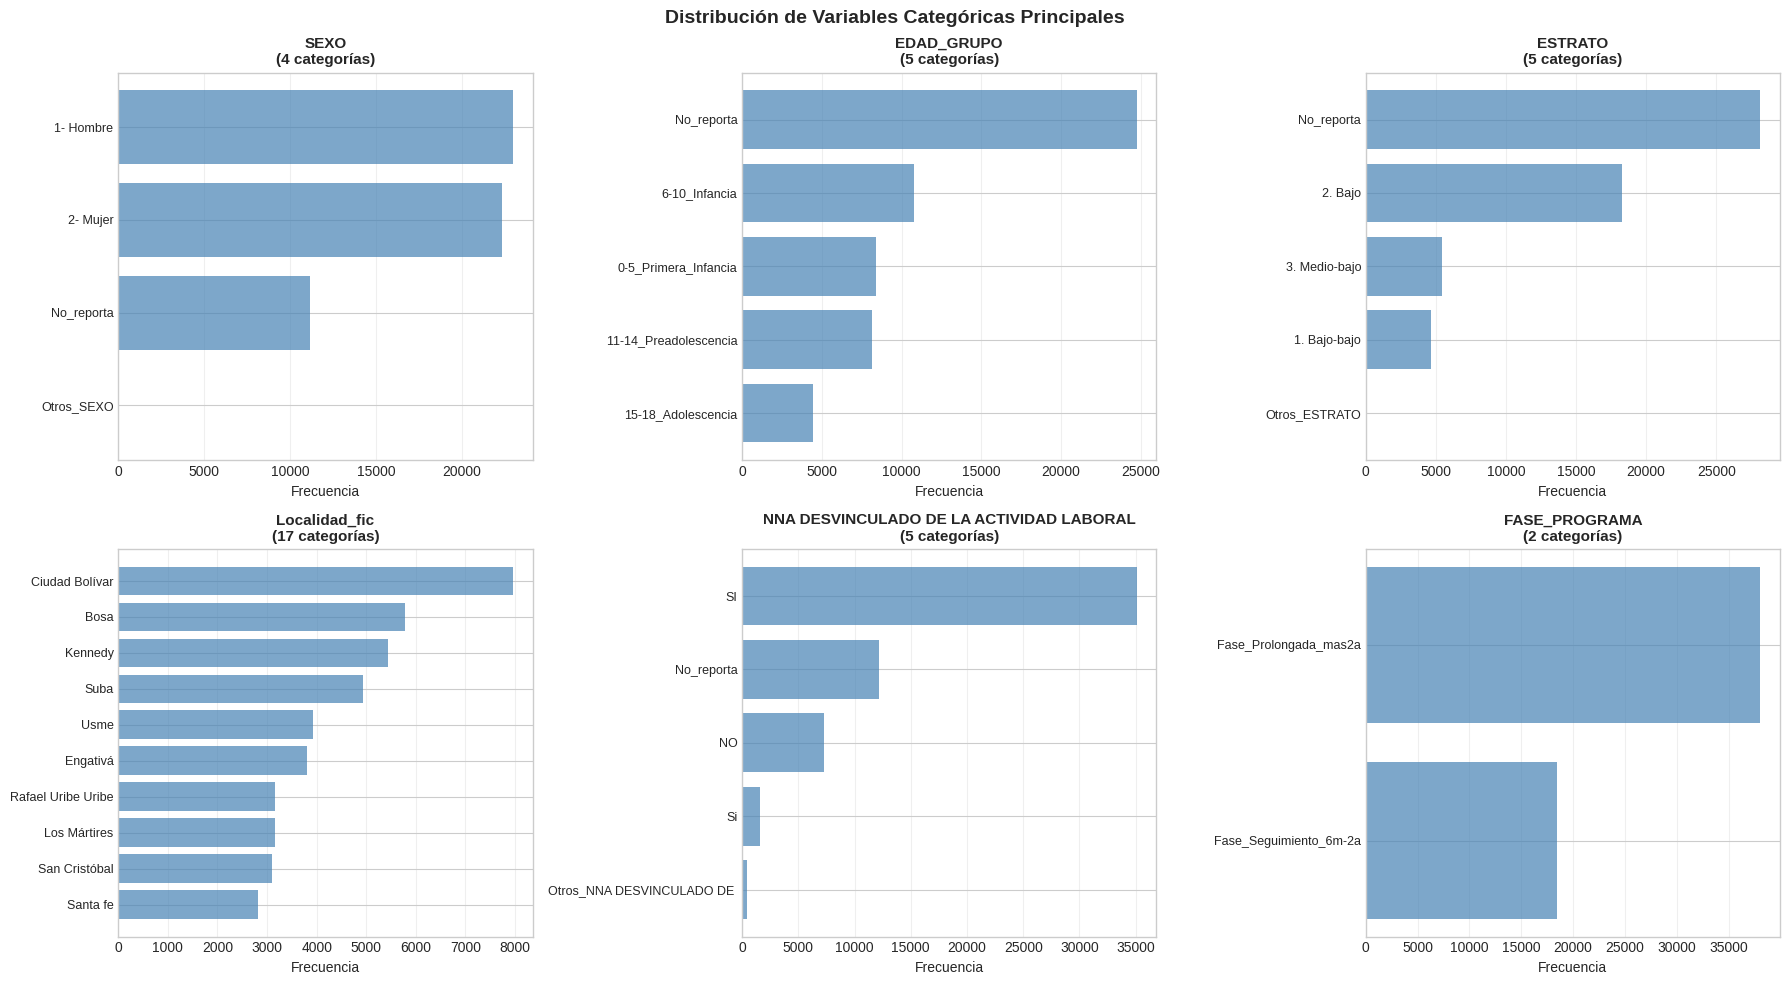

In [31]:
# ==============================================================================
# 9. VISUALIZACIÓN EXPLORATORIA
# ==============================================================================

print("\n" + "=" * 80)
print(" VISUALIZACIÓN EXPLORATORIA")
print("=" * 80)

# Seleccionar 6 variables clave para visualizar
vars_clave = [
    'SEXO',
    'EDAD_GRUPO',
    'ESTRATO',
    'Localidad_fic',
    'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL',
    'FASE_PROGRAMA' if 'FASE_PROGRAMA' in datos_mca.columns else variables_mca[0]
]

# Filtrar las que existen
vars_plot = [v for v in vars_clave if v in datos_mca.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(vars_plot):
    freq = datos_mca[var].value_counts().head(10)

    axes[idx].barh(range(len(freq)), freq.values, color='steelblue', alpha=0.7)
    axes[idx].set_yticks(range(len(freq)))
    axes[idx].set_yticklabels([str(cat)[:30] for cat in freq.index], fontsize=9)
    axes[idx].set_xlabel('Frecuencia', fontsize=10)
    axes[idx].set_title(f'{var}\n({datos_mca[var].nunique()} categorías)',
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()

plt.suptitle('Distribución de Variables Categóricas Principales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ==============================================================================
# 10. EXPORTACIÓN
# ==============================================================================

print("\n" + "=" * 80)
print(" EXPORTACIÓN DE RESULTADOS")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

# 10.1 Dataset MCA
csv_mca = ruta_salida + "datos_mca_preparados.csv"
datos_mca.to_csv(csv_mca, index=False)
print(f"\n✅ Dataset MCA guardado:")
print(f"   {csv_mca}")
print(f"    Shape: {datos_mca.shape}")

# 10.2 Metadatos
metadata = pd.DataFrame([{
    'fecha_procesamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'registros': datos_mca.shape[0],
    'variables_categoricas': datos_mca.shape[1],
    'variables_nuevas': len(nuevas_categoricas),
    'total_categorias': sum([datos_mca[col].nunique() for col in datos_mca.columns]),
    'umbral_agrupacion': umbral_frecuencia
}])

metadata_csv = ruta_salida + "metadata_mca.csv"
metadata.to_csv(metadata_csv, index=False)
print(f"\n Metadatos guardados:")
print(f"   {metadata_csv}")

# 10.3 Diccionario de variables
diccionario = pd.DataFrame({
    'Variable': datos_mca.columns,
    'N_Categorias': [datos_mca[col].nunique() for col in datos_mca.columns],
    'Categoria_Principal': [datos_mca[col].value_counts().index[0] for col in datos_mca.columns],
    'Freq_Principal_%': [datos_mca[col].value_counts(normalize=True).iloc[0] * 100 for col in datos_mca.columns]
})

diccionario_xlsx = ruta_salida + "diccionario_variables_mca.xlsx"
diccionario.to_excel(diccionario_xlsx, index=False)
print(f"\n Diccionario de variables guardado:")
print(f"    {diccionario_xlsx}")



 EXPORTACIÓN DE RESULTADOS

✅ Dataset MCA guardado:
   /content/drive/MyDrive/Python/Proyecto NNA/datos_mca_preparados.csv
    Shape: (56473, 21)

 Metadatos guardados:
   /content/drive/MyDrive/Python/Proyecto NNA/metadata_mca.csv

 Diccionario de variables guardado:
    /content/drive/MyDrive/Python/Proyecto NNA/diccionario_variables_mca.xlsx


In [33]:
# ==============================================================================
# 11. RESUMEN EJECUTIVO
# ==============================================================================

print("\n" + "=" * 80)
print(" RESUMEN EJECUTIVO - DATA PREPARATION PARA MCA")
print("=" * 80)

print(f"""
✅ PROCESO COMPLETADO EXITOSAMENTE

DATASET FINAL PARA MCA:
   • Registros: {datos_mca.shape[0]:,}
   • Variables categóricas: {datos_mca.shape[1]}
   • Total de categorías: {sum([datos_mca[col].nunique() for col in datos_mca.columns]):,}

TRANSFORMACIONES APLICADAS:
   ✅ {len(variables_disponibles)} variables categóricas originales
   ✅ {len(nuevas_categoricas)} variables discretizadas (EDAD_GRUPO, etc.)
   ✅ Limpieza y estandarización de categorías
   ✅ Agrupación de categorías raras (<{umbral_frecuencia*100}%)
   ✅ Imputación con 'No_reporta'

ARCHIVOS GENERADOS:
   1. datos_mca_preparados.csv (dataset principal)
   2. metadata_mca.csv (información del proceso)
   3. diccionario_variables_mca.xlsx (detalle de variables)

PRÓXIMO PASO: MODELING
   → Notebook 3: Análisis de Correspondencias Múltiples (MCA)
   → Interpretación de dimensiones y perfiles
""")

print("=" * 80)
print("✅ FASE DATA PREPARATION COMPLETADA")
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


 RESUMEN EJECUTIVO - DATA PREPARATION PARA MCA

✅ PROCESO COMPLETADO EXITOSAMENTE

DATASET FINAL PARA MCA:
   • Registros: 56,473
   • Variables categóricas: 21
   • Total de categorías: 100
   
TRANSFORMACIONES APLICADAS:
   ✅ 18 variables categóricas originales
   ✅ 3 variables discretizadas (EDAD_GRUPO, etc.)
   ✅ Limpieza y estandarización de categorías
   ✅ Agrupación de categorías raras (<2.0%)
   ✅ Imputación con 'No_reporta'

ARCHIVOS GENERADOS:
   1. datos_mca_preparados.csv (dataset principal)
   2. metadata_mca.csv (información del proceso)
   3. diccionario_variables_mca.xlsx (detalle de variables)

PRÓXIMO PASO: MODELING
   → Notebook 3: Análisis de Correspondencias Múltiples (MCA)
   → Interpretación de dimensiones y perfiles

✅ FASE DATA PREPARATION COMPLETADA
Fecha: 2025-10-16 17:21:47
